# End-to-End Customer Churn Prediction System

---

## Project Overview

| Field | Details |
|-------|---------|
| **Problem Type** | Binary Classification (Supervised Learning) |
| **Target Variable** | Churn (1 = Churned, 0 = Retained) |
| **Dataset** | Customer Churn Dataset (Training + Testing) |
| **Models Used** | Logistic Regression, K-Nearest Neighbors (KNN) |
| **Evaluation** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |

---

## Problem Statement

> **Predict whether a customer will churn (leave a service) based on historical customer data.**

Customer churn is a critical business metric. Losing a customer costs significantly more than retaining one.  

## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Step 2: Load the Dataset


In [2]:
train_df = pd.read_csv('Customer-Churn-Dataset/customer_churn_dataset-training.csv')
test_df  = pd.read_csv('Customer-Churn-Dataset/customer_churn_dataset-testing.csv')

print(f"Training set shape : {train_df.shape}")
print(f"Testing  set shape : {test_df.shape}")

# Combine for full EDA (we will split again after preprocessing)
df = pd.concat([train_df, test_df], ignore_index=True)

# Drop the 1 row where Churn is NaN (training CSV quirk)
rows_before = len(df)
df.dropna(subset=['Churn'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows dropped (Churn NaN): {rows_before - len(df)}")

# Cast Churn float64 -> int  (fixes seaborn palette dict mismatch)
df['Churn'] = df['Churn'].astype(int)

print(f"Combined dataset shape : {df.shape}")
print(f"Churn dtype            : {df['Churn'].dtype}")

Training set shape : (440833, 12)
Testing  set shape : (64374, 12)
Rows dropped (Churn NaN): 1
Combined dataset shape : (505206, 12)
Churn dtype            : int64


In [3]:
# Preview the first 10 rows
df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1


In [4]:
# Column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  int64  
dtypes: float64(8), int64(1), str(3)
memory usage: 46.3 MB


In [5]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,505206.0,200779.451782,137241.343095,1.0,63827.25,193039.5,321645.75,449999.0
Age,505206.0,39.704172,12.670577,18.0,29.00,40.0,49.00,65.0
Tenure,505206.0,31.350435,17.237482,1.0,16.00,32.0,46.00,60.0
Usage Frequency,505206.0,15.714825,8.619323,1.0,8.00,16.0,23.00,30.0
Support Calls,505206.0,3.833317,3.133603,0.0,1.00,3.0,6.00,10.0
Payment Delay,505206.0,13.496843,8.451187,0.0,6.00,13.0,20.00,30.0
Total Spend,505206.0,620.072766,245.319256,100.0,446.00,648.9,824.00,1000.0
Last Interaction,505206.0,14.610581,8.608286,1.0,7.00,14.0,22.00,30.0
Churn,505206.0,0.555203,0.496944,0.0,0.00,1.0,1.00,1.0


## Step 3: Exploratory Data Analysis (EDA)

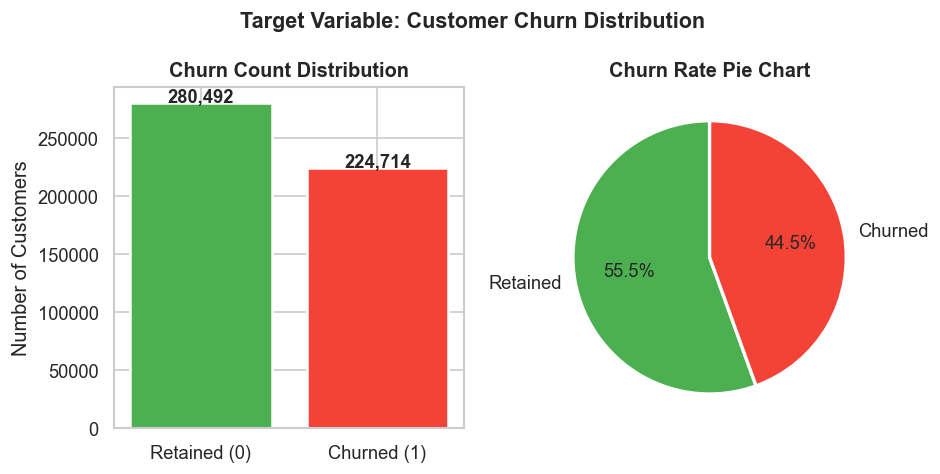


Churn Rate: 55.5%


In [6]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Pie Chart', fontweight='bold')

plt.suptitle('Target Variable: Customer Churn Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nChurn Rate: {churn_counts[1] / len(df) * 100:.1f}%")


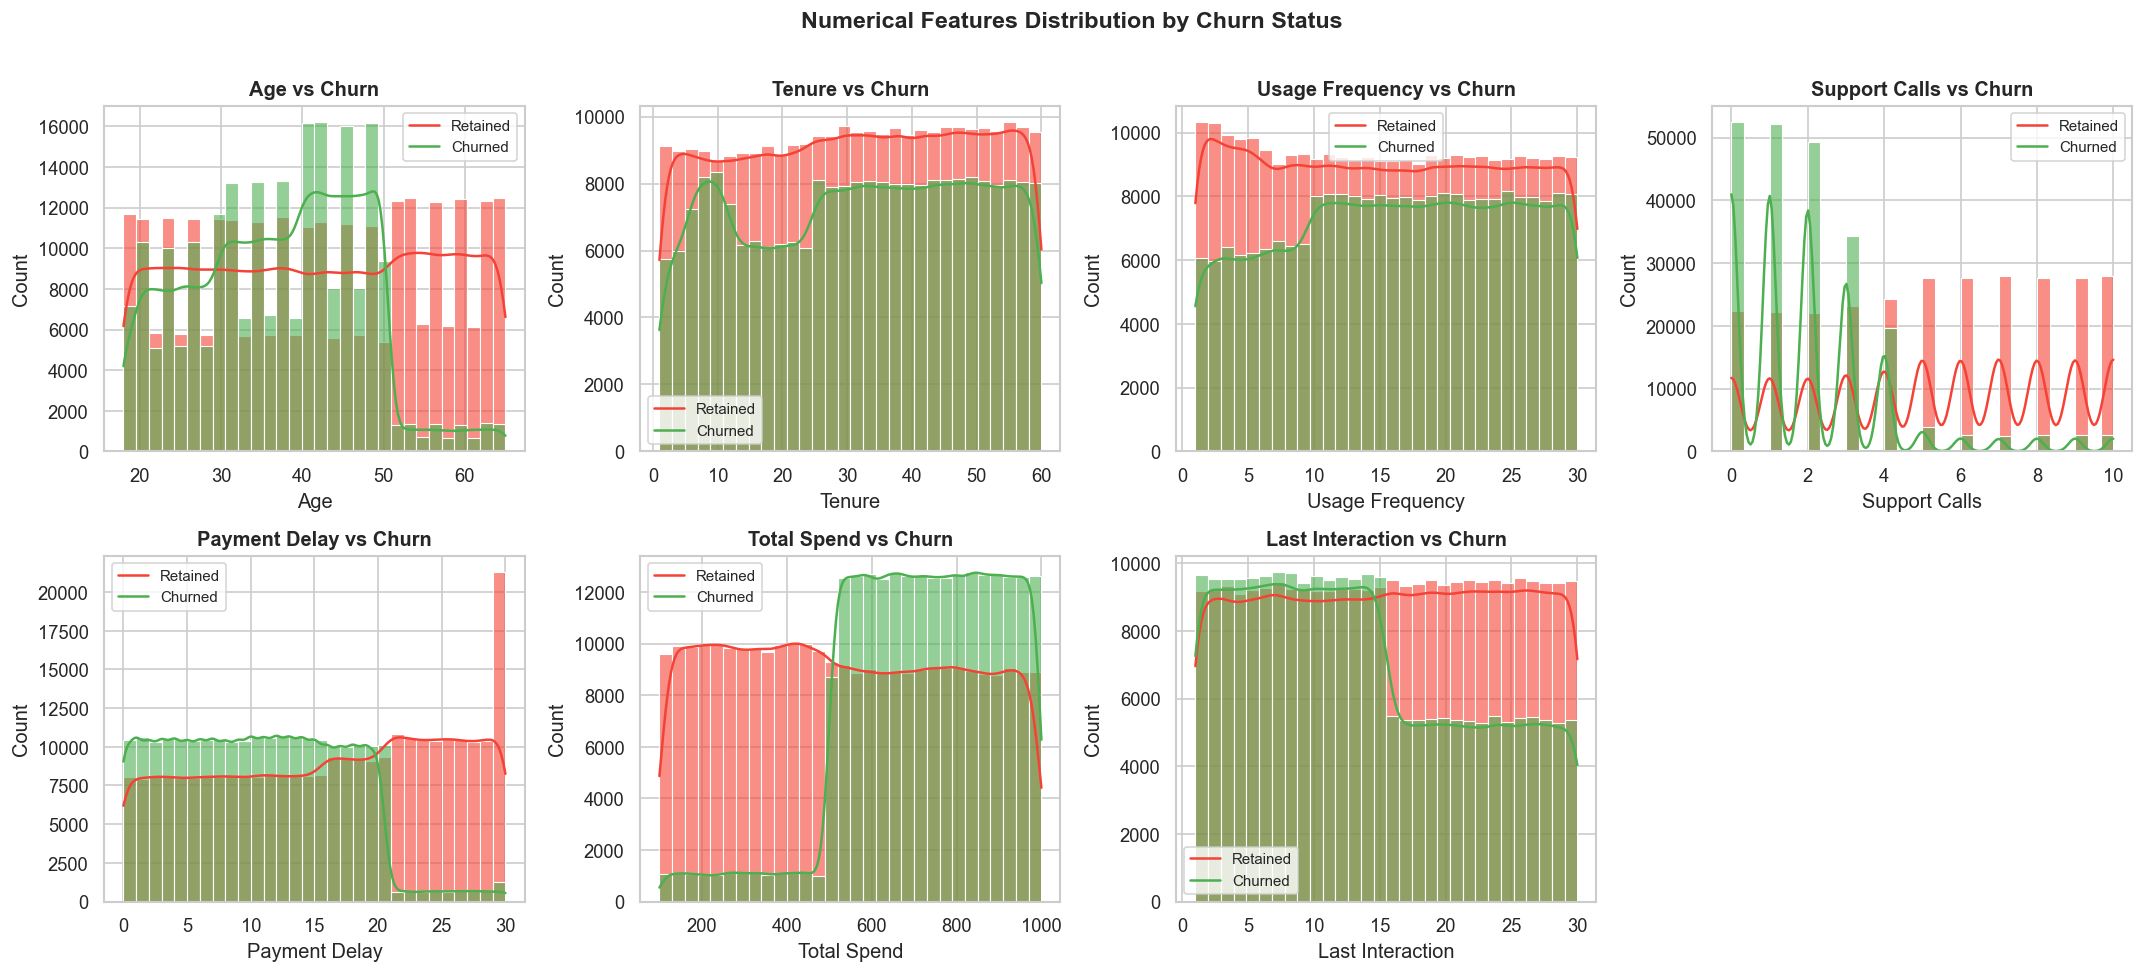

In [7]:
# Numerical Feature Distributions
numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                  'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True,
                 ax=axes[i], palette=['#4CAF50', '#F44336'], alpha=0.6)
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[i].legend(['Retained', 'Churned'], fontsize=9)

# Hide the unused subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Features Distribution by Churn Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_02_numerical_distributions.png', bbox_inches='tight')
plt.show()

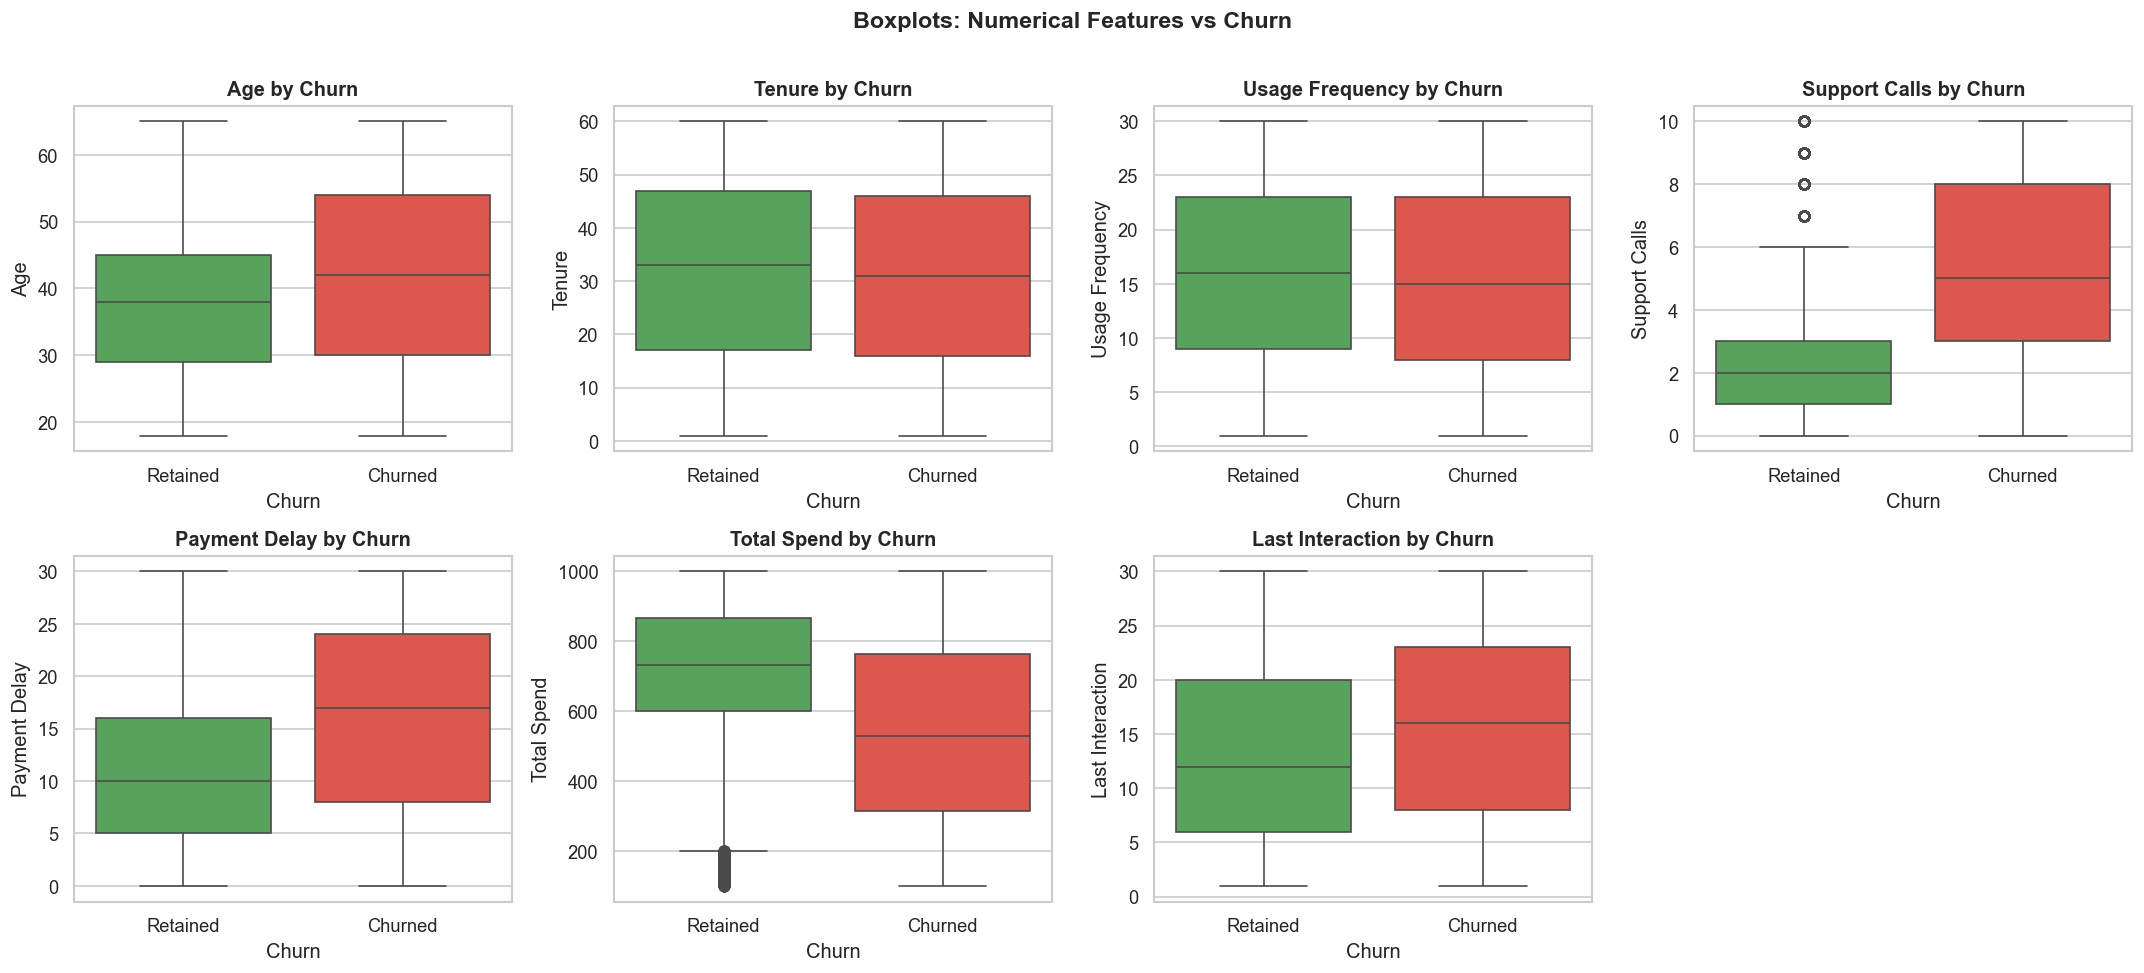

In [8]:
# Boxplots: Numerical Features vs Churn
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i],
                palette=['#4CAF50', '#F44336'])
    axes[i].set_title(f'{col} by Churn', fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])

axes[-1].set_visible(False)

plt.suptitle('Boxplots: Numerical Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_boxplots.png', bbox_inches='tight')
plt.show()

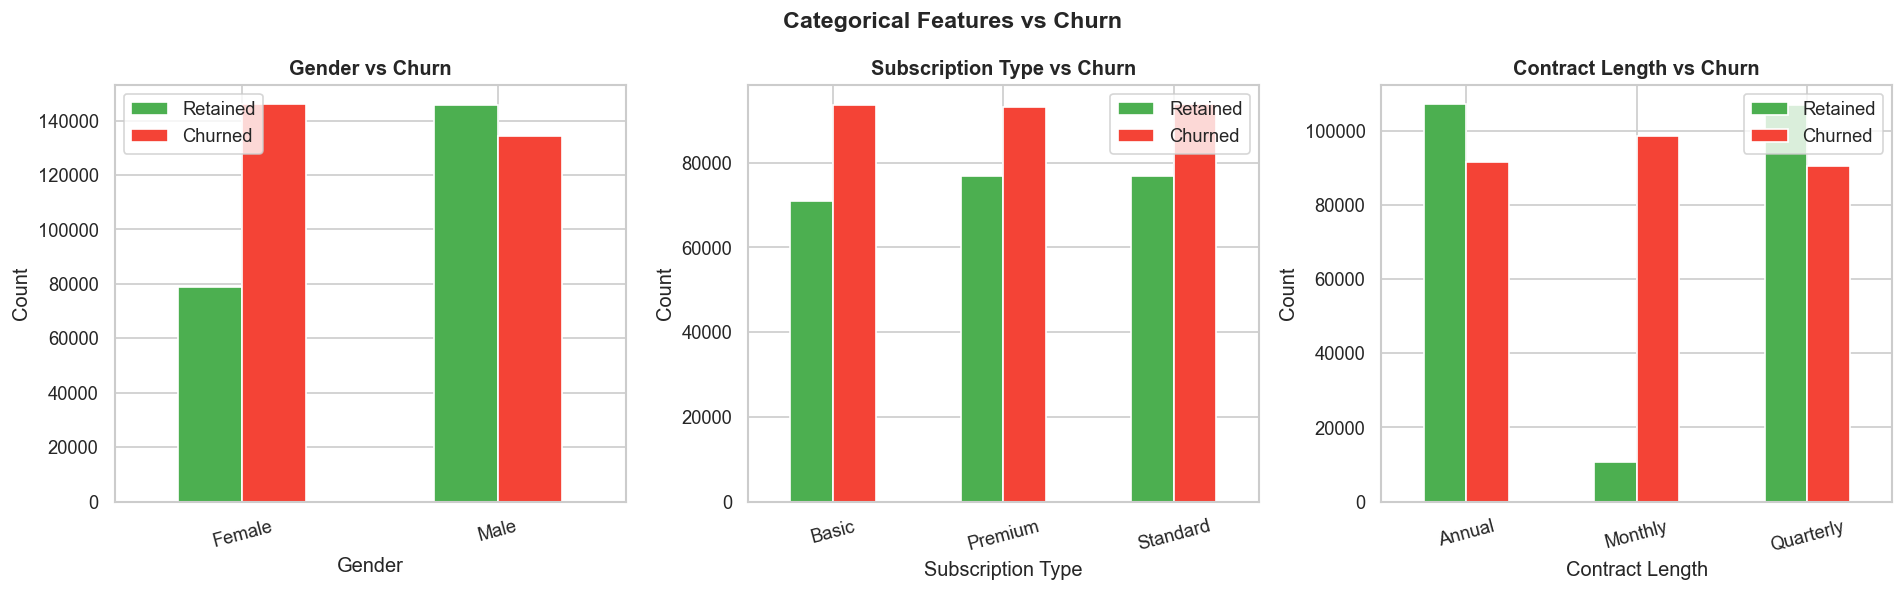

In [9]:
# Categorical Features vs Churn
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    ct = df.groupby([col, 'Churn']).size().unstack()
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', linewidth=1)
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['Retained', 'Churned'])
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_categorical_vs_churn.png', bbox_inches='tight')
plt.show()

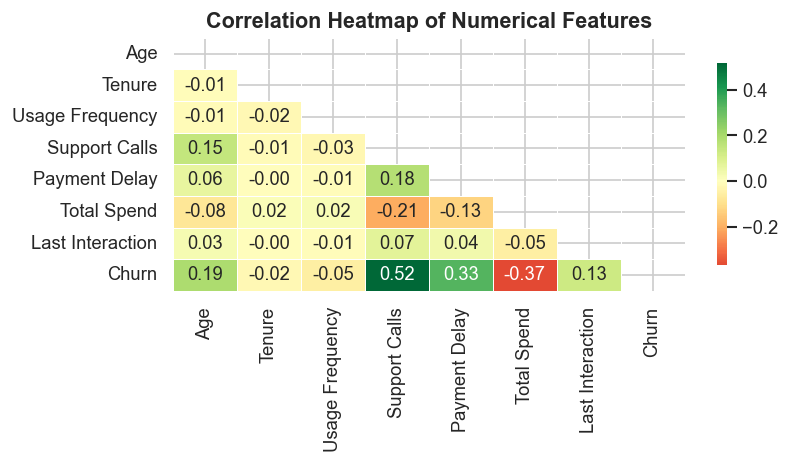

In [10]:
# Correlation Heatmap
plt.figure(figsize=(7, 4))
corr_matrix = df[numerical_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

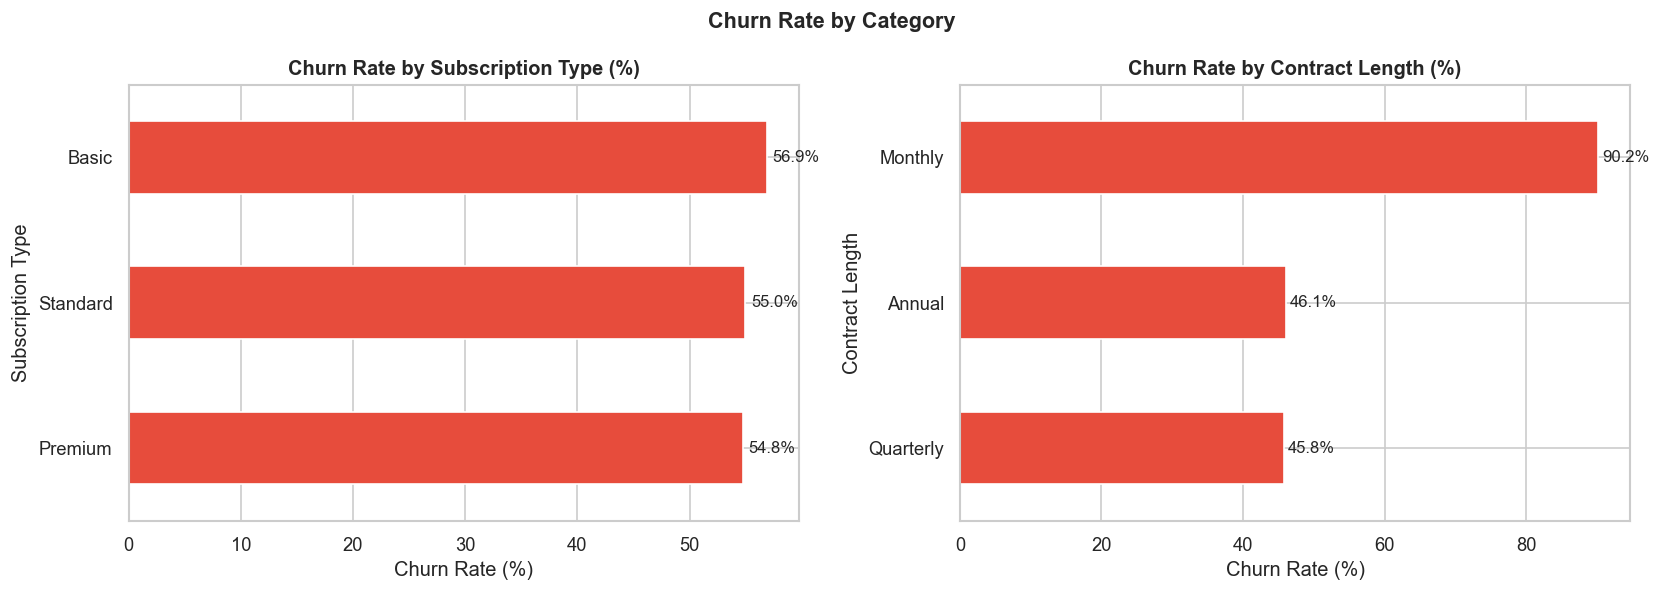

In [11]:
# Churn Rate by Subscription Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Subscription Type', 'Contract Length']):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.sort_values().plot(kind='barh', ax=ax,
                                  color='#E74C3C', edgecolor='white')
    ax.set_title(f'Churn Rate by {col} (%)', fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.1f}%",
                    (p.get_width() + 0.5, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=10)

plt.suptitle('Churn Rate by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_churn_rate_by_category.png', bbox_inches='tight')
plt.show()

## Step 4: Handle Missing Values

In [12]:
# Check missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [13]:
# For numerical columns: fill with MEDIAN (robust to outliers)
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled '{col}' missing values with median = {median_val}")

# For categorical columns: fill with MODE
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled '{col}' missing values with mode = {mode_val}")

# For CustomerID and Churn: drop if null (identifier / target)
df.dropna(subset=['CustomerID', 'Churn'], inplace=True)

print(f"\nTotal missing values after handling: {df.isnull().sum().sum()}")
print(f"Dataset shape after cleaning: {df.shape}")


Total missing values after handling: 0
Dataset shape after cleaning: (505206, 12)


<a id="5"></a>
## Step 5: Encode Categorical Variables

Two common strategies:

 **Label Encoding** --> Converts each category to an integer (0, 1, 2…) 

 **One-Hot Encoding** --> Creates a binary column for each category 

In our dataset:
- **Gender** --> One-Hot Encoding (Male/Female – no order)
- **Subscription Type** --> One-Hot Encoding (Basic/Standard/Premium – no inherent order)
- **Contract Length** --> Label Encoding (Annual > Quarterly > Monthly – ordinal nature)


In [14]:
# Show unique values before encoding
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    print(f"{col}: {df[col].unique()}")

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Subscription Type: <StringArray>
['Standard', 'Basic', 'Premium']
Length: 3, dtype: str
Contract Length: <StringArray>
['Annual', 'Monthly', 'Quarterly']
Length: 3, dtype: str


In [15]:
# Label Encoding: Contract Length (Ordinal)
le = LabelEncoder()
contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}

df['Contract Length Encoded'] = df['Contract Length'].map(contract_map)
print("Contract Length → Label Encoded:")
print(df[['Contract Length', 'Contract Length Encoded']].drop_duplicates())

Contract Length → Label Encoded:
  Contract Length  Contract Length Encoded
0          Annual                        2
1         Monthly                        0
2       Quarterly                        1


In [16]:
# One-Hot Encoding: Gender and Subscription Type
df_encoded = pd.get_dummies(df.drop(columns=['Contract Length']),
                             columns=['Gender', 'Subscription Type'],
                             drop_first=False)

# Preview encoded columns
print("Columns after encoding:")
print(df_encoded.columns.tolist())
df_encoded.head(3)

Columns after encoding:
['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Contract Length Encoded', 'Gender_Female', 'Gender_Male', 'Subscription Type_Basic', 'Subscription Type_Premium', 'Subscription Type_Standard']


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Contract Length Encoded,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1,2,True,False,False,False,True
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1,0,True,False,True,False,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1,1,True,False,True,False,False


## Step 6: Scale Numerical Features

Feature scaling ensures all features contribute equally to the model.  
Without scaling, features with large ranges (e.g., Total Spend) dominate distance-based algorithms like KNN.

**StandardScaler** transforms each feature to have:
- **Mean = 0**
- **Standard Deviation = 1**

Formula: `z = (x - μ) / σ`


In [17]:
# Define Features and Target
X = df_encoded.drop(columns=['CustomerID', 'Churn'])
y = df_encoded['Churn'].astype(int)

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nFeatures used:\n{X.columns.tolist()}")

Feature matrix shape : (505206, 13)
Target vector shape  : (505206,)

Features used:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Contract Length Encoded', 'Gender_Female', 'Gender_Male', 'Subscription Type_Basic', 'Subscription Type_Premium', 'Subscription Type_Standard']


## Step 7: Train-Test Split

In [18]:
SAMPLE_SIZE = 50_000
np.random.seed(42)

if len(X) > SAMPLE_SIZE:
    sample_idx = X.sample(n=SAMPLE_SIZE, random_state=42).index
    X_sample = X.loc[sample_idx]
    y_sample = y.loc[sample_idx]
    print(f"Sampled {SAMPLE_SIZE:,} rows from {len(X):,} total rows for efficient training.")
else:
    X_sample, y_sample = X, y

# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f"\nTraining set : {X_train.shape[0]:,} rows")
print(f"Testing  set : {X_test.shape[0]:,} rows")
print(f"\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True).rename({0: 'Retained', 1: 'Churned'}))

Sampled 50,000 rows from 505,206 total rows for efficient training.

Training set : 40,000 rows
Testing  set : 10,000 rows

Churn distribution in training set:
Churn
Churned     0.557175
Retained    0.442825
Name: proportion, dtype: float64


In [19]:
# Apply StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # transform test with SAME scaler

print("Feature scaling complete.")
print(f"Train feature means (first 3): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Train feature stds  (first 3): {X_train_scaled[:, :3].std(axis=0).round(4)}")

Feature scaling complete.
Train feature means (first 3): [ 0. -0.  0.]
Train feature stds  (first 3): [1. 1. 1.]


## Step 8: Model Training

### Model 1: Logistic Regression
- Linear model for binary classification
- Outputs probability scores via the sigmoid function
- Fast, interpretable, good baseline

### Model 2: K-Nearest Neighbors (KNN)
- Non-parametric, instance-based learner
- Classifies based on the K closest training examples
- Sensitive to feature scale (hence StandardScaler is critical)


In [20]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [21]:
# Train KNN
print("\nTraining K-Nearest Neighbors (k=5)...")
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)
print("KNN trained.")


Training K-Nearest Neighbors (k=5)...
KNN trained.


Finding optimal K for KNN

Best K = 7  (Accuracy = 0.8852)


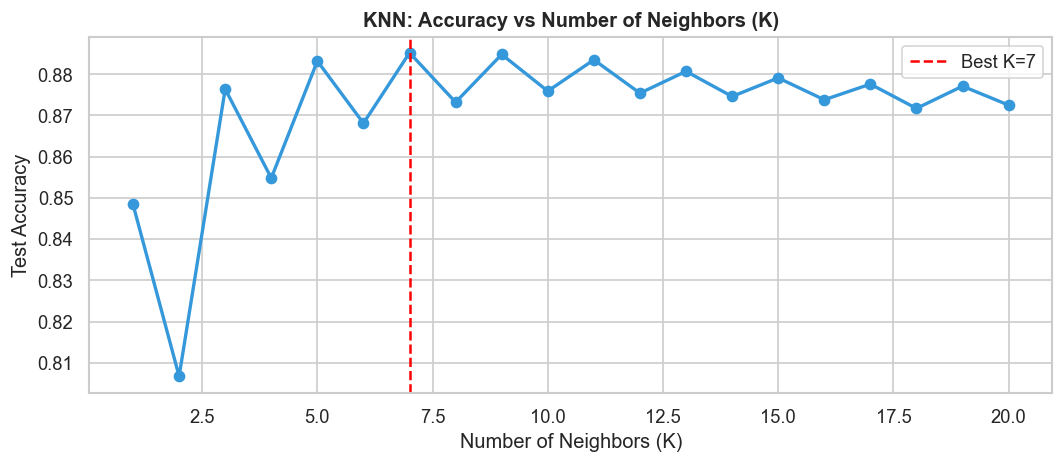

KNN retrained with best K=7


In [22]:
# Finding Optimal K for KNN
print("Finding optimal K for KNN")
k_range = range(1, 21)
k_scores = []

for k in k_range:
    temp_knn = KNeighborsClassifier(n_neighbors=k)
    temp_knn.fit(X_train_scaled, y_train)
    score = accuracy_score(y_test, temp_knn.predict(X_test_scaled))
    k_scores.append(score)

best_k = k_range[k_scores.index(max(k_scores))]
print(f"\nBest K = {best_k}  (Accuracy = {max(k_scores):.4f})")

# Plot K vs Accuracy
plt.figure(figsize=(9, 4))
plt.plot(k_range, k_scores, marker='o', color='#3498DB', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN: Accuracy vs Number of Neighbors (K)', fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('plot_07_knn_k_selection.png', bbox_inches='tight')
plt.show()

# Retrain with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
print(f"KNN retrained with best K={best_k}")

## Step 9: Model Evaluation & Comparison

### Key Metrics Explained

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Overall correct predictions |
| **Precision** | TP / (TP + FP) | Of all predicted churns, how many were real? |
| **Recall** | TP / (TP + FN) | Of all actual churns, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Balance between Precision and Recall |
| **Confusion Matrix** | - | Full breakdown: TP, FP, TN, FN |

> In churn prediction, Recall is often more important than Precision missing a churner (False Negative) is more costly than a false alarm.


In [23]:
# Generate Predictions
y_pred_log  = log_reg.predict(X_test_scaled)
y_pred_knn  = knn_best.predict(X_test_scaled)

y_prob_log  = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn  = knn_best.predict_proba(X_test_scaled)[:, 1]

# Evaluation Function
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1-Score' : round(f1_score(y_true, y_pred), 4),
    }

metrics_log = get_metrics(y_test, y_pred_log, 'Logistic Regression')
metrics_knn = get_metrics(y_test, y_pred_knn, f'KNN (k={best_k})')

# Print Classification Reports
print("=" * 55)
print("  LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_log,
      target_names=['Retained (0)', 'Churned (1)']))

print("=" * 55)
print(f"  KNN (k={best_k}) — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_knn,
      target_names=['Retained (0)', 'Churned (1)']))

  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

Retained (0)       0.80      0.83      0.82      4428
 Churned (1)       0.86      0.84      0.85      5572

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000

  KNN (k=7) — Classification Report
              precision    recall  f1-score   support

Retained (0)       0.86      0.88      0.87      4428
 Churned (1)       0.91      0.89      0.90      5572

    accuracy                           0.89     10000
   macro avg       0.88      0.89      0.88     10000
weighted avg       0.89      0.89      0.89     10000



In [24]:
# Evaluation Summary Table
summary_df = pd.DataFrame([metrics_log, metrics_knn])
summary_df = summary_df.set_index('Model')

print("\n" + "=" * 55)
print("        MODEL EVALUATION SUMMARY TABLE ")
print("=" * 55)
print(summary_df.to_string())
print("=" * 55)

summary_df.style.highlight_max(axis=0, color='#90EE90').format("{:.4f}")


        MODEL EVALUATION SUMMARY TABLE 
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8342     0.8617  0.8367    0.8490
KNN (k=7)              0.8852     0.9056  0.8864    0.8959


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8342,0.8617,0.8367,0.8490
KNN (k=7),0.8852,0.9056,0.8864,0.8959


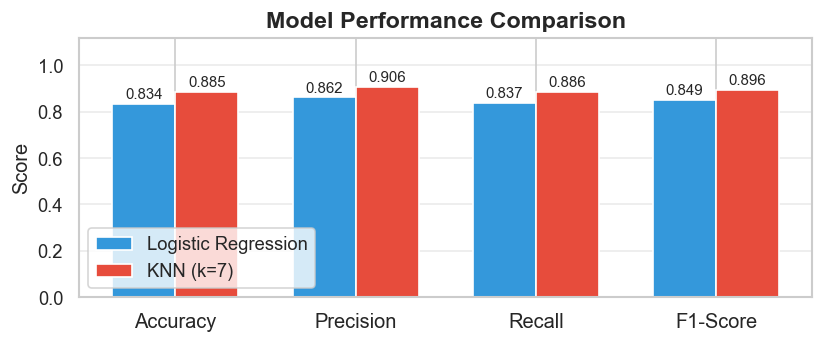

In [25]:
# Bar Chart: Metric Comparison
metrics_plot = summary_df.copy()
x = np.arange(len(metrics_plot.columns))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 3))

bars1 = ax.bar(x - width/2, metrics_plot.iloc[0], width,
               label='Logistic Regression', color='#3498DB', edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_plot.iloc[1], width,
               label=f'KNN (k={best_k})', color='#E74C3C', edgecolor='white')

ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot.columns, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', bbox_inches='tight')
plt.show()

## Step 10: Confusion Matrix Visualization


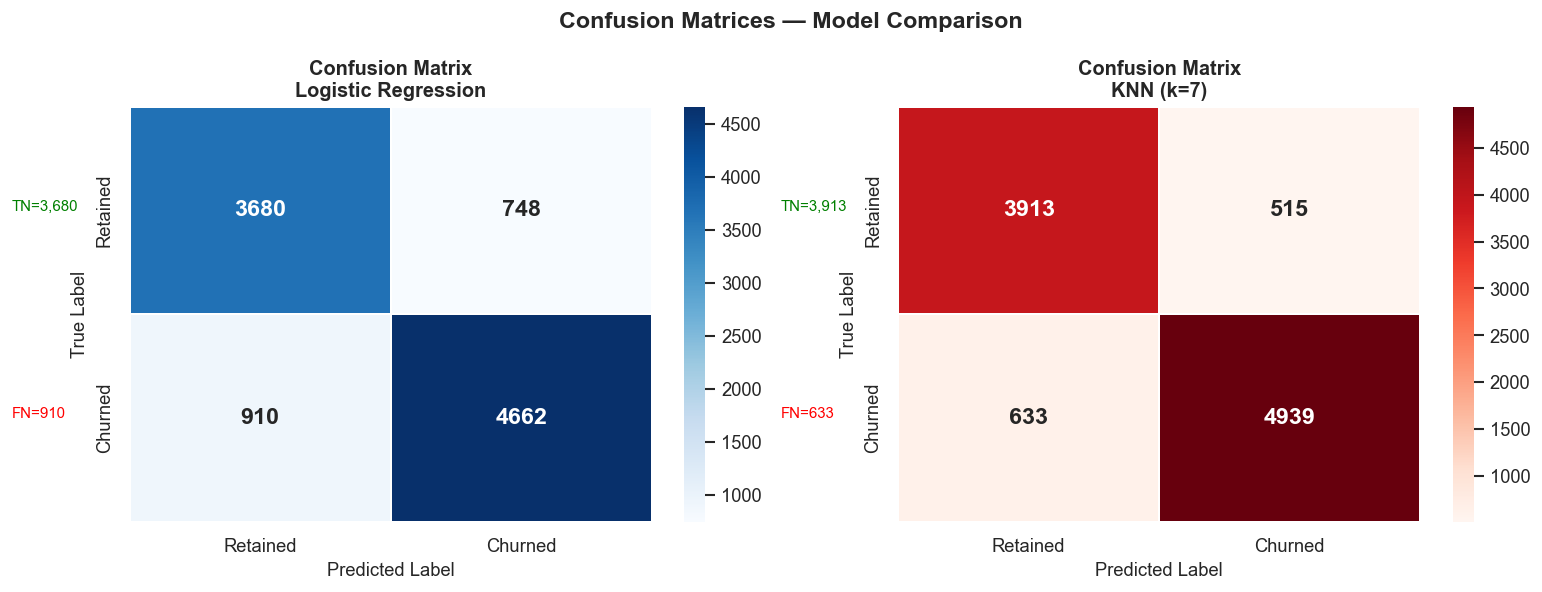

In [26]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_log, y_pred_knn],
    ['Logistic Regression', f'KNN (k={best_k})'],
    ['Blues', 'Reds']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

    tn, fp, fn, tp = cm.ravel()
    ax.text(-0.45, 0.5, f'TN={tn:,}', color='green', fontsize=9)
    ax.text(-0.45, 1.5, f'FN={fn:,}', color='red', fontsize=9)

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_09_confusion_matrices.png', bbox_inches='tight')
plt.show()

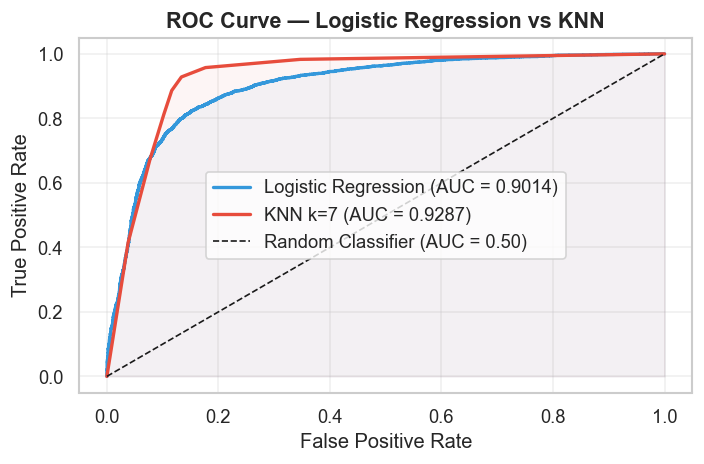


Logistic Regression AUC : 0.9014
KNN (k=7) AUC         : 0.9287


In [27]:
# ROC Curves 
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_log = auc(fpr_log, tpr_log)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6, 4))
plt.plot(fpr_log, tpr_log, color='#3498DB', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_log:.4f})')
plt.plot(fpr_knn, tpr_knn, color='#E74C3C', linewidth=2,
         label=f'KNN k={best_k} (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr_log, tpr_log, alpha=0.05, color='#3498DB')
plt.fill_between(fpr_knn, tpr_knn, alpha=0.05, color='#E74C3C')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression vs KNN', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_10_roc_curves.png', bbox_inches='tight')
plt.show()

print(f"\nLogistic Regression AUC : {auc_log:.4f}")
print(f"KNN (k={best_k}) AUC         : {auc_knn:.4f}")

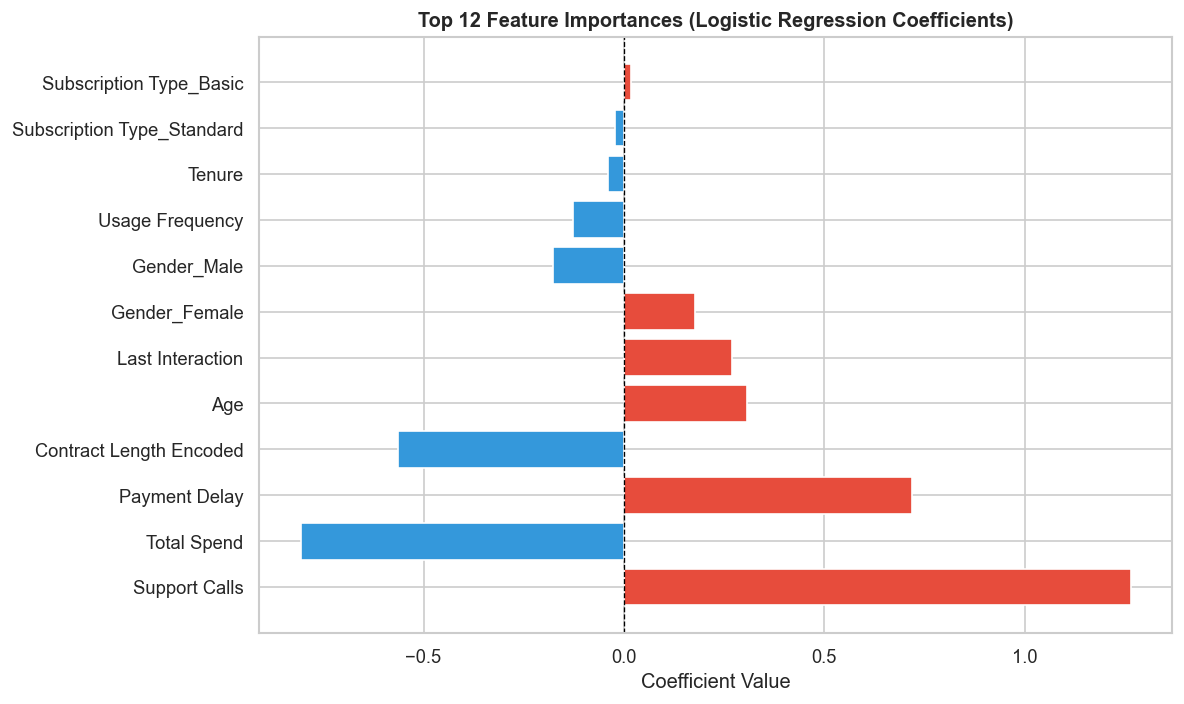

In [28]:
# Feature Importance (Logistic Regression Coefficients) 
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(12)

plt.figure(figsize=(10, 6))
colors = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 12 Feature Importances (Logistic Regression Coefficients)',
          fontweight='bold', fontsize=12)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plot_11_feature_importance.png', bbox_inches='tight')
plt.show()

## Step 11: Overfitting vs Underfitting

### Definitions

| Concept | Description | Symptoms |
|---------|-------------|---------|
| **Underfitting** | Model too simple to capture the true pattern | High train error, High test error |
| **Good Fit** | Model generalizes well | Low train error, Low test error |
| **Overfitting** | Model memorizes training data, fails on new data | Low train error, High test error |

In [29]:
# Illustrate Overfitting with KNN at K=1 (memorizes training)
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_train_scaled, y_train)
train_acc_k1 = accuracy_score(y_train, knn_k1.predict(X_train_scaled))
test_acc_k1  = accuracy_score(y_test, knn_k1.predict(X_test_scaled))

# KNN at optimal K
train_acc_best = accuracy_score(y_train, knn_best.predict(X_train_scaled))
test_acc_best  = accuracy_score(y_test, knn_best.predict(X_test_scaled))

# Logistic Regression (typically underfits complex patterns)
train_acc_lr = accuracy_score(y_train, log_reg.predict(X_train_scaled))
test_acc_lr  = accuracy_score(y_test, log_reg.predict(X_test_scaled))

print("Model Behavior Analysis:")
print("-" * 55)
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 55)
for name, tr, te in [
    ('KNN (k=1) [Overfit]',    train_acc_k1,   test_acc_k1),
    (f'KNN (k={best_k}) [Good Fit]', train_acc_best, test_acc_best),
    ('Logistic Reg [Underfit?]', train_acc_lr,  test_acc_lr),
]:
    gap = abs(tr - te)
    print(f"{name:<25} {tr:>10.4f} {te:>10.4f} {gap:>8.4f}")
print("-" * 55)

Model Behavior Analysis:
-------------------------------------------------------
Model                      Train Acc   Test Acc      Gap
-------------------------------------------------------
KNN (k=1) [Overfit]           1.0000     0.8484   0.1516
KNN (k=7) [Good Fit]          0.8977     0.8852   0.0125
Logistic Reg [Underfit?]      0.8313     0.8342   0.0030
-------------------------------------------------------


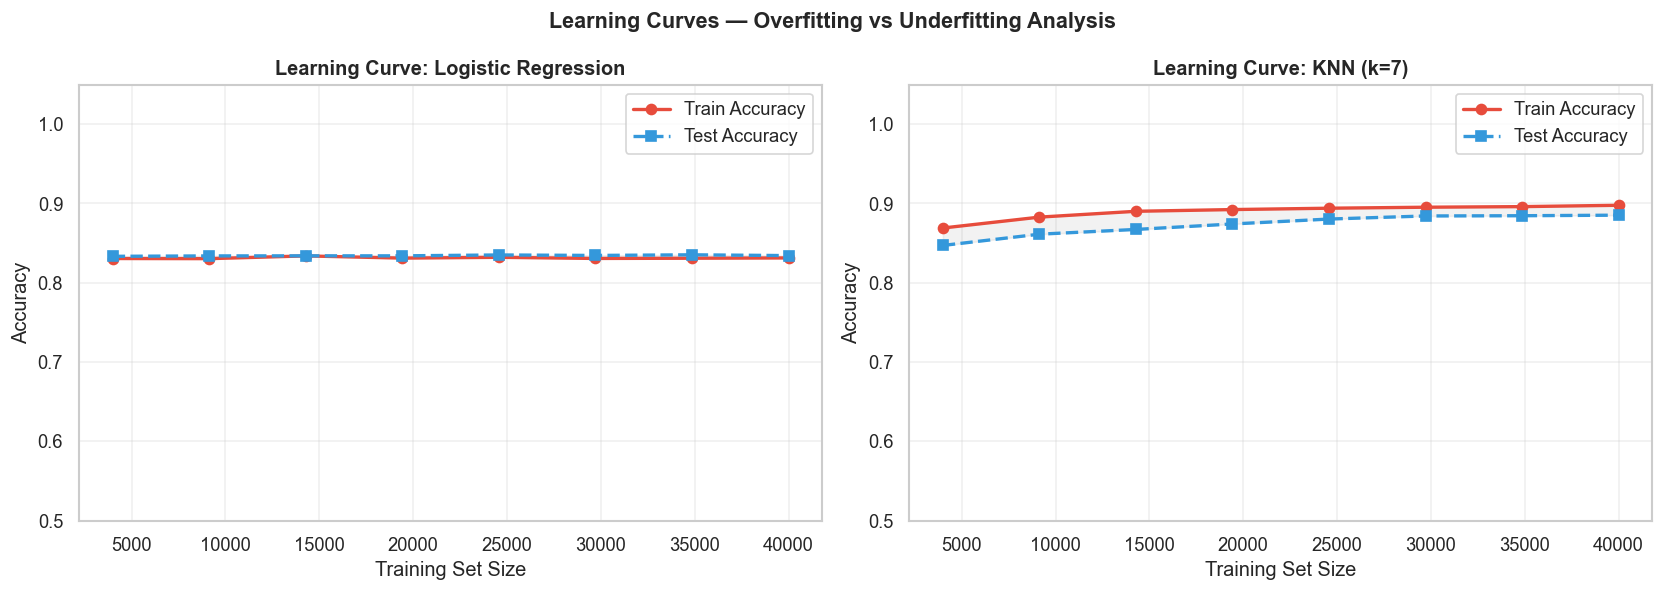


 Interpretation:
Large gap between Train and Test → Overfitting
Both Train & Test low → Underfitting
Train ≈ Test (high) → Good Generalization


In [30]:
# Learning Curve: Training Accuracy vs Training Size
train_sizes = np.linspace(0.1, 1.0, 8)
lr_train_scores, lr_test_scores = [], []
knn_train_scores, knn_test_scores = [], []

for size in train_sizes:
    n = int(len(X_train_scaled) * size)
    Xtr, ytr = X_train_scaled[:n], y_train.values[:n]

    # Logistic Regression
    lr_tmp = LogisticRegression(random_state=42, max_iter=500)
    lr_tmp.fit(Xtr, ytr)
    lr_train_scores.append(accuracy_score(ytr, lr_tmp.predict(Xtr)))
    lr_test_scores.append(accuracy_score(y_test, lr_tmp.predict(X_test_scaled)))

    # KNN best
    knn_tmp = KNeighborsClassifier(n_neighbors=best_k)
    knn_tmp.fit(Xtr, ytr)
    knn_train_scores.append(accuracy_score(ytr, knn_tmp.predict(Xtr)))
    knn_test_scores.append(accuracy_score(y_test, knn_tmp.predict(X_test_scaled)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_counts = [int(len(X_train_scaled) * s) for s in train_sizes]

for ax, tr_sc, te_sc, title in zip(
    axes,
    [lr_train_scores, knn_train_scores],
    [lr_test_scores, knn_test_scores],
    ['Logistic Regression', f'KNN (k={best_k})']
):
    ax.plot(train_counts, tr_sc, 'o-', color='#E74C3C', label='Train Accuracy', linewidth=2)
    ax.plot(train_counts, te_sc, 's--', color='#3498DB', label='Test Accuracy', linewidth=2)
    ax.fill_between(train_counts, tr_sc, te_sc, alpha=0.1, color='gray')
    ax.set_title(f'Learning Curve: {title}', fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.05)

plt.suptitle('Learning Curves — Overfitting vs Underfitting Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_12_learning_curves.png', bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("Large gap between Train and Test --> Overfitting")
print("Both Train & Test low --> Underfitting")
print("Train ≈ Test (high) --> Good Generalization")

## Step 12: Conclusions & Summary

### Key Findings

1. **Dataset**: ~505K customer records with 11 features + 1 target (Churn)
2. **Missing Values**: Extremely minimal; handled using median/mode imputation
3. **Encoding**: One-Hot Encoding for Gender & Subscription Type; Label Encoding for Contract Length
4. **Scaling**: StandardScaler ensured fair treatment of all features

### Model Comparison Summary

| Model | Strength | Weakness |
|-------|---------|---------|
| **Logistic Regression** | Fast, interpretable, stable | Assumes linear boundaries |
| **KNN** | Non-linear boundaries, flexible | Slow on large data, sensitive to K |

### Business Insights

- Customers with **high Support Calls** are most likely to churn
- **Monthly Contract** customers churn more than Annual
- **Payment Delay** is a strong predictor of churn
- Targeted retention offers should focus on customers with declining `Last Interaction` days

### Next Steps (Beyond Scope)
- Try ensemble models: Random Forest, XGBoost
- Apply SMOTE for class imbalance handling
- Hyperparameter tuning with GridSearchCV
- Deploy the model as a REST API (Flask/FastAPI)
- Build a real-time churn scoring dashboard

## Step 13: Churn Predictor

Fill in the customer details below and click **Predict Churn**.
Both models will show:
- **Prediction verdict + probability**
- **Why?** - key risk factors driving the prediction (from actual model weights & neighbor analysis)
- **Risk profile table** comparing the customer vs average churned/retained customers
- **Two embedded charts** for visual explanation


In [ ]:

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import io, base64

matplotlib.use('Agg')   # render to buffer, not screen (avoids double display)

# Pre-compute training stats (churned vs retained)
churned_mask  = (y_train == 1)
retained_mask = (y_train == 0)
churned_means  = X_train[churned_mask].mean()
retained_means = X_train[retained_mask].mean()

RAW_FEATURES = [
    'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
    'Payment Delay', 'Total Spend', 'Last Interaction',
]
DISPLAY_NAMES = {
    'Age': 'Age',
    'Tenure': 'Tenure (months)',
    'Usage Frequency': 'Usage Frequency',
    'Support Calls': 'Support Calls',
    'Payment Delay': 'Payment Delay (days)',
    'Total Spend': 'Total Spend ($)',
    'Last Interaction': 'Last Interaction (days ago)',
    'Contract Length Encoded': 'Contract Type (encoded)',
    'Gender_Female': 'Gender: Female',
    'Gender_Male': 'Gender: Male',
    'Subscription Type_Basic': 'Subscription: Basic',
    'Subscription Type_Premium': 'Subscription: Premium',
    'Subscription Type_Standard': 'Subscription: Standard',
}

# Helper: build input row 
def build_input_row(age, tenure, usage_freq, support_calls,
                    payment_delay, total_spend, last_interaction,
                    gender, sub_type, contract_len):
    contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
    row = {
        'Age': age, 'Tenure': tenure,
        'Usage Frequency': usage_freq, 'Support Calls': support_calls,
        'Payment Delay': payment_delay, 'Total Spend': total_spend,
        'Last Interaction': last_interaction,
        'Contract Length Encoded': contract_map[contract_len],
        'Gender_Female': 1 if gender == 'Female' else 0,
        'Gender_Male':   1 if gender == 'Male'   else 0,
        'Subscription Type_Basic':    1 if sub_type == 'Basic'    else 0,
        'Subscription Type_Premium':  1 if sub_type == 'Premium'  else 0,
        'Subscription Type_Standard': 1 if sub_type == 'Standard' else 0,
    }
    df_row = pd.DataFrame([row])
    df_row = df_row.reindex(columns=X_train.columns, fill_value=0)
    return df_row

# Helper: simple LR natural-language reason
def lr_reason_text(feat, raw_val, contribution, churned_m, retained_m):
    dn  = DISPLAY_NAMES.get(feat, feat)
    direction = "pushes toward CHURN" if contribution > 0 else "supports RETENTION"
    if feat in RAW_FEATURES:
        c_avg = churned_m.get(feat, None)
        r_avg = retained_m.get(feat, None)
        if c_avg is not None:
            cmp = "above" if raw_val > r_avg else "below"
            return (
                f"<b>{dn}</b> = {raw_val:.0f} | avg churned: {c_avg:.1f}, "
                f"avg retained: {r_avg:.1f}. "
                f"This value is {cmp} the retained average and <i>{direction}</i>."
            )
    return f"<b>{dn}</b> {direction} (LR contribution: {contribution:+.3f})."

# Widgets
style  = {'description_width': '160px'}
layout = widgets.Layout(width='420px')

w_age      = widgets.IntSlider(value=35, min=18, max=65, step=1,   description='Age',                    style=style, layout=layout)
w_tenure   = widgets.IntSlider(value=24, min=1,  max=60, step=1,   description='Tenure (months)',        style=style, layout=layout)
w_usage    = widgets.IntSlider(value=15, min=1,  max=30, step=1,   description='Usage Frequency',        style=style, layout=layout)
w_support  = widgets.IntSlider(value=3,  min=0,  max=10, step=1,   description='Support Calls',          style=style, layout=layout)
w_delay    = widgets.IntSlider(value=10, min=0,  max=30, step=1,   description='Payment Delay (days)',   style=style, layout=layout)
w_spend    = widgets.IntSlider(value=500,min=100,max=1000,step=10, description='Total Spend ($)',         style=style, layout=layout)
w_last     = widgets.IntSlider(value=15, min=1,  max=30, step=1,   description='Last Interaction (days)',style=style, layout=layout)
w_gender   = widgets.Dropdown(options=['Female','Male'],   value='Male',     description='Gender',            style=style, layout=layout)
w_sub      = widgets.Dropdown(options=['Basic','Standard','Premium'], value='Standard', description='Subscription Type', style=style, layout=layout)
w_contract = widgets.Dropdown(options=['Monthly','Quarterly','Annual'],value='Monthly',description='Contract Length',   style=style, layout=layout)

btn = widgets.Button(description='Predict Churn', button_style='danger',
                     layout=widgets.Layout(width='200px', height='40px'))
out = widgets.Output()

# Helper: fig -> base64 png
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# Prediction callback
def on_predict(b):
    with out:
        clear_output(wait=True)

        raw_vals = dict(
            age=w_age.value, tenure=w_tenure.value, usage_freq=w_usage.value,
            support_calls=w_support.value, payment_delay=w_delay.value,
            total_spend=w_spend.value, last_interaction=w_last.value,
            gender=w_gender.value, sub_type=w_sub.value, contract_len=w_contract.value
        )
        row_df     = build_input_row(**raw_vals)
        row_scaled = scaler.transform(row_df)

        # Predictions
        lr_pred  = int(log_reg.predict(row_scaled)[0])
        lr_prob  = log_reg.predict_proba(row_scaled)[0]
        knn_pred = int(knn_best.predict(row_scaled)[0])
        knn_prob = knn_best.predict_proba(row_scaled)[0]

        # LR Feature Contributions: coef_i × scaled_val_i
        contributions = log_reg.coef_[0] * row_scaled[0]
        contrib_df = pd.DataFrame({'Feature': X_train.columns, 'Contribution': contributions})
        contrib_df['AbsContrib'] = contrib_df['Contribution'].abs()
        contrib_df = contrib_df.sort_values('AbsContrib', ascending=False).head(12)
        top_churn_f = contrib_df[contrib_df['Contribution'] > 0].head(5)
        top_stay_f  = contrib_df[contrib_df['Contribution'] < 0].head(3)

        # KNN neighbour analysis
        distances, indices = knn_best.kneighbors(row_scaled)
        neighbor_labels = [int(y_train.iloc[idx]) for idx in indices[0]]
        n_churn_nn = sum(neighbor_labels)
        n_stay_nn  = len(neighbor_labels) - n_churn_nn
        avg_dist   = distances[0].mean()

        # Risk factor table data
        feat_raw_map = {
            'Age': raw_vals['age'], 'Tenure': raw_vals['tenure'],
            'Usage Frequency': raw_vals['usage_freq'],
            'Support Calls': raw_vals['support_calls'],
            'Payment Delay': raw_vals['payment_delay'],
            'Total Spend': raw_vals['total_spend'],
            'Last Interaction': raw_vals['last_interaction'],
        }
        risk_rows = []
        for feat, val in feat_raw_map.items():
            c_avg = churned_means[feat]
            r_avg = retained_means[feat]
            closer_to_churn = abs(val - c_avg) <= abs(val - r_avg)
            risk_rows.append((feat, val, c_avg, r_avg, closer_to_churn))

        # Build verdict snippet
        def verdict_html(pred, prob):
            color = '#E74C3C' if pred == 1 else '#27AE60'
            label = 'WILL CHURN' if pred == 1 else 'WILL STAY'
            return (
                f'<span style="color:{color};font-weight:bold;font-size:15px">'
                f'{label}</span> &nbsp;'
                f'<span style="color:{color}">(Churn probability: '
                f'<b>{prob[1]*100:.1f}%</b>)</span>'
            )

        # LR churn reason bullets
        churn_bullets = ''.join(
            f'<li style="margin:4px 0; color:#C0392B">'
            f'{lr_reason_text(r["Feature"], feat_raw_map.get(r["Feature"], "N/A"), r["Contribution"], churned_means, retained_means)}'
            f'</li>'
            for _, r in top_churn_f.iterrows()
        )
        stay_bullets = ''.join(
            f'<li style="margin:4px 0; color:#27AE60">'
            f'{lr_reason_text(r["Feature"], feat_raw_map.get(r["Feature"], "N/A"), r["Contribution"], churned_means, retained_means)}'
            f'</li>'
            for _, r in top_stay_f.iterrows()
        )

        # Risk factor table rows
        risk_table_rows = ''
        for feat, val, c_avg, r_avg, is_risk in risk_rows:
            bg    = '#FDEDEC' if is_risk else '#EAFAF1'
            badge = ('<span style="color:#E74C3C;font-weight:bold">RISK</span>'
                     if is_risk else
                     '<span style="color:#27AE60;font-weight:bold">OK</span>')
            risk_table_rows += (
                f'<tr style="background:{bg}">'
                f'<td style="padding:6px 10px">{feat}</td>'
                f'<td style="padding:6px 10px;text-align:center"><b>{val}</b></td>'
                f'<td style="padding:6px 10px;text-align:center">{c_avg:.1f}</td>'
                f'<td style="padding:6px 10px;text-align:center">{r_avg:.1f}</td>'
                f'<td style="padding:6px 10px;text-align:center">{badge}</td>'
                f'</tr>'
            )

        # Chart 1: LR Feature Contributions
        fig1, ax1 = plt.subplots(figsize=(9, 4))
        chart_df = contrib_df.sort_values('Contribution')
        colors1  = ['#E74C3C' if c > 0 else '#27AE60' for c in chart_df['Contribution']]
        disp_names = [DISPLAY_NAMES.get(f, f) for f in chart_df['Feature']]
        bars = ax1.barh(disp_names, chart_df['Contribution'], color=colors1, edgecolor='white', linewidth=0.6)
        ax1.axvline(0, color='black', linewidth=0.9, linestyle='--')
        ax1.set_title('Logistic Regression: Feature Contributions\n'
                      'RED = pushes toward CHURN  |  GREEN = pushes toward STAY',
                      fontsize=10, fontweight='bold')
        ax1.set_xlabel('Log-Odds Contribution  (coef × scaled value)', fontsize=9)
        ax1.tick_params(labelsize=8)
        # Annotate bar ends
        for bar, val in zip(bars, chart_df['Contribution']):
            x_pos = bar.get_width() + (0.005 if val >= 0 else -0.005)
            ha    = 'left' if val >= 0 else 'right'
            ax1.text(x_pos, bar.get_y() + bar.get_height()/2,
                     f'{val:+.3f}', va='center', ha=ha, fontsize=7.5)
        fig1.tight_layout()
        img1 = fig_to_base64(fig1)

        # Chart 2: Customer vs Avg Churned vs Avg Retained (key features)
        key_feats_chart = ['Support Calls', 'Payment Delay', 'Tenure',
                           'Total Spend', 'Usage Frequency', 'Last Interaction', 'Age']
        key_feats_chart = [f for f in key_feats_chart if f in churned_means.index]

        cust_vals  = np.array([feat_raw_map[f] for f in key_feats_chart], dtype=float)
        churn_vals = np.array([churned_means[f]  for f in key_feats_chart], dtype=float)
        stay_vals  = np.array([retained_means[f] for f in key_feats_chart], dtype=float)

        # Normalise to [0,1] using training min/max for each feature
        tr_min = X_train[key_feats_chart].min().values
        tr_max = X_train[key_feats_chart].max().values
        rng    = np.where(tr_max > tr_min, tr_max - tr_min, 1)
        cust_n  = (cust_vals  - tr_min) / rng
        churn_n = (churn_vals - tr_min) / rng
        stay_n  = (stay_vals  - tr_min) / rng

        x2     = np.arange(len(key_feats_chart))
        w2     = 0.26
        fig2, ax2 = plt.subplots(figsize=(11, 4))
        ax2.bar(x2 - w2,   cust_n,  w2, label='This Customer', color='#2E86C1', edgecolor='white')
        ax2.bar(x2,         churn_n, w2, label='Avg Churned',   color='#E74C3C', edgecolor='white', alpha=0.8)
        ax2.bar(x2 + w2,   stay_n,  w2, label='Avg Retained',  color='#27AE60', edgecolor='white', alpha=0.8)
        ax2.set_xticks(x2)
        ax2.set_xticklabels(key_feats_chart, rotation=20, ha='right', fontsize=9)
        ax2.set_ylabel('Normalised Value [0-1]', fontsize=9)
        ax2.set_title('Customer Profile vs Average Churned / Average Retained\n'
                      '(All features normalised to 0-1 for comparison)',
                      fontsize=10, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.set_ylim(0, 1.15)
        ax2.yaxis.grid(True, alpha=0.3)
        fig2.tight_layout()
        img2 = fig_to_base64(fig2)

        # Assemble final HTML
        overall_verdict = 'WILL CHURN' if (lr_pred == 1 or knn_pred == 1) else 'WILL STAY'
        banner_color    = '#E74C3C' if overall_verdict == 'WILL CHURN' else '#27AE60'

        html = f"""
<div style="font-family:Arial,sans-serif; max-width:920px; border:2px solid #2C3E50;
            border-radius:10px; overflow:hidden; margin-top:10px;">

  <!-- BANNER -->
  <div style="background:{banner_color}; color:white; padding:10px 18px; font-size:17px; font-weight:bold;">
    Overall Verdict: {overall_verdict}
  </div>

  <!-- SECTION 1: Prediction Results -->
  <div style="padding:14px 18px; background:#F9F9F9; border-bottom:1px solid #ddd;">
    <b style="font-size:13px; color:#2C3E50;">Prediction Results</b>
    <table style="width:100%; border-collapse:collapse; margin-top:8px;">
      <tr style="background:#2C3E50; color:white;">
        <th style="padding:7px 10px; text-align:left;">Model</th>
        <th style="padding:7px 10px; text-align:left;">Verdict</th>
      </tr>
      <tr style="background:#EBF5FB;">
        <td style="padding:7px 10px; font-weight:bold;">Logistic Regression</td>
        <td style="padding:7px 10px;">{verdict_html(lr_pred, lr_prob)}</td>
      </tr>
      <tr style="background:#FDFEFE;">
        <td style="padding:7px 10px; font-weight:bold;">KNN (k={best_k})</td>
        <td style="padding:7px 10px;">{verdict_html(knn_pred, knn_prob)}</td>
      </tr>
    </table>
  </div>

  <!-- SECTION 2: WHY? -->
  <div style="padding:14px 18px; background:#fff; border-bottom:1px solid #ddd;">
    <b style="font-size:13px; color:#2C3E50;">Why? — Model-Based Explanation</b>

    <div style="margin-top:10px;">
      <span style="background:#E74C3C; color:white; padding:3px 8px; border-radius:4px;
                   font-size:11px; font-weight:bold;">LOGISTIC REGRESSION</span>
      <p style="margin:8px 0 4px; font-size:12px; color:#555;">
        LR assigns a weight to each feature. Multiplying weight × scaled value gives the
        <b>contribution</b> of each feature to the churn probability.
        Positive = pushes toward churn; Negative = pushes toward retention.
      </p>

      <div style="font-size:12px; margin-top:6px;">
        <b style="color:#C0392B;">Top Churn Risk Factors:</b>
        <ul style="margin:4px 0 8px 16px;">{churn_bullets}</ul>

        <b style="color:#1E8449;">Retention Signals (working against churn):</b>
        <ul style="margin:4px 0 8px 16px;">{stay_bullets}</ul>
      </div>
    </div>

    <div style="margin-top:12px;">
      <span style="background:#8E44AD; color:white; padding:3px 8px; border-radius:4px;
                   font-size:11px; font-weight:bold;">KNN (k={best_k})</span>
      <p style="font-size:12px; color:#555; margin:8px 0;">
        KNN found the <b>{best_k} most similar historical customers</b> to this profile
        (average distance = <b>{avg_dist:.3f}</b> in scaled feature space).<br>
        Of those {best_k} neighbours:
        <span style="color:#E74C3C; font-weight:bold;">{n_churn_nn} churned</span> and
        <span style="color:#27AE60; font-weight:bold;">{n_stay_nn} stayed</span>.
        {'<br><b>Conclusion: The overwhelming majority of similar customers churned.</b>'
          if n_churn_nn > n_stay_nn else
          '<br><b>Conclusion: The majority of similar customers stayed.</b>'}
      </p>
    </div>
  </div>

  <!-- SECTION 3: Risk Factor Table -->
  <div style="padding:14px 18px; background:#F9F9F9; border-bottom:1px solid #ddd;">
    <b style="font-size:13px; color:#2C3E50;">Customer Risk Profile
      <span style="font-size:10px; font-weight:normal; color:#666;">
        — compared to training-set averages</span></b>
    <table style="width:100%; border-collapse:collapse; margin-top:8px; font-size:12px;">
      <tr style="background:#2C3E50; color:white;">
        <th style="padding:6px 10px; text-align:left;">Feature</th>
        <th style="padding:6px 10px; text-align:center;">Customer Value</th>
        <th style="padding:6px 10px; text-align:center;">Avg Churned</th>
        <th style="padding:6px 10px; text-align:center;">Avg Retained</th>
        <th style="padding:6px 10px; text-align:center;">Status</th>
      </tr>
      {risk_table_rows}
    </table>
    <p style="font-size:11px; color:#888; margin-top:6px;">
      RISK = customer's value is closer to the average churned customer's value.
    </p>
  </div>

  <!-- SECTION 4: Charts -->
  <div style="padding:14px 18px; background:#fff;">
    <b style="font-size:13px; color:#2C3E50;">Visual Explanation</b>
    <div style="margin-top:10px; text-align:center;">
      <img src="data:image/png;base64,{img1}" style="max-width:100%; border-radius:6px;"/>
    </div>
    <div style="margin-top:12px; text-align:center;">
      <img src="data:image/png;base64,{img2}" style="max-width:100%; border-radius:6px;"/>
    </div>
  </div>

</div>
"""
        display(HTML(html))

btn.on_click(on_predict)

# Layout
title   = widgets.HTML('<h3 style="color:#2C3E50;font-family:Arial">Enter Customer Details</h3>')
left_c  = widgets.VBox([w_age, w_tenure, w_usage, w_support, w_delay])
right_c = widgets.VBox([w_spend, w_last, w_gender, w_sub, w_contract])
display(widgets.VBox([title, widgets.HBox([left_c, right_c]),
                      widgets.HBox([btn]), out]))
